In [ ]:
# @title Version
# ── This is the only line you need to update when releasing a new version ──
NOTEBOOK_VERSION = "1.0.0"


# IC50 Dose-Response Analysis
Upload `plate_layout.xlsx` and the plate reader `.xlsx` when prompted in Cell 2.

**Pipeline:**
1. Reads plate layout → builds well-position lookup (plate, row, col) → (cell_line_lot, compound_lot, conc_nM)
2. Reads plate reader file → finds sheet named `"1"`, `"2"` etc., extracts luminescence per well
3. Joins on (plate, row, col) → long-format table
4. Normalises to control wells → relative viability
5. Fits 4-parameter logistic per cell_line_lot × compound_lot → IC50, Hill, R²
6. Plots dose-response curves, saves results CSV


In [1]:
# @title Cell 1 — Install & import
!pip install openpyxl --quiet
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from openpyxl import load_workbook
from google.colab import files
import warnings, io, os
warnings.filterwarnings("ignore")
print("Ready.")

# ── Version check ─────────────────────────────────────────────
# Compares running version against latest on GitHub.
# If you opened this from the Colab link you are already up to date.
GITHUB_RAW_URL = (
    "https://raw.githubusercontent.com/"
    "atlas-biotech/IC50_analysis/main/IC50_Analysis.ipynb"
)
try:
    import requests
    resp = requests.get(GITHUB_RAW_URL, timeout=5)
    if resp.status_code == 200:
        remote_nb = resp.json()
        latest_ver = None
        for cell in remote_nb["cells"]:
            for line in cell["source"]:
                if "NOTEBOOK_VERSION" in line and "=" in line:
                    latest_ver = line.split('"')[1]
                    break
            if latest_ver:
                break
        if latest_ver and latest_ver != NOTEBOOK_VERSION:
            print(f"⚠️  You are running version {NOTEBOOK_VERSION}. "
                  f"Latest is {latest_ver}.")
            print("   Open from the GitHub Colab link to get the latest version.")
        else:
            print(f"✅  IC50 Analysis  v{NOTEBOOK_VERSION}  (up to date)")
    else:
        print(f"ℹ️  IC50 Analysis  v{NOTEBOOK_VERSION}  (could not reach GitHub to check)")
except Exception:
    print(f"ℹ️  IC50 Analysis  v{NOTEBOOK_VERSION}  (version check skipped — no network)")


Ready.


In [2]:
# @title Cell 2 — Upload files
print("Upload plate_layout.xlsx")
uploaded = files.upload()
layout_fname = [k for k in uploaded if 'layout' in k.lower() or k.endswith('.xlsx')][0]

print("\nUpload plate reader .xlsx")
uploaded2 = files.upload()
reader_fname = [k for k in uploaded2.keys()][0]
print(f"\nLayout : {layout_fname}")
print(f"Reader : {reader_fname}")


Upload plate_layout.xlsx


Saving plate_layout_test1154_2026-06-25.xlsx to plate_layout_test1154_2026-06-25.xlsx

Upload plate reader .xlsx


Saving Imat_Asc_ResMuts_260608.xlsx to Imat_Asc_ResMuts_260608.xlsx

Layout : plate_layout_test1154_2026-06-25.xlsx
Reader : Imat_Asc_ResMuts_260608.xlsx


In [3]:
# @title Cell 3 — Parse plate layout

DOSE_COUNT     = 9
CTRL_PLATE_COL = 11
EDGE_COLS      = {1, 12}
EDGE_ROWS      = {"A", "H"}
VALID_ROWS     = set("BCDEFG")

# Plate Maps geometry
BLOCK_H          = 13          # rows per plate block
CONC_ROW_OFFSET  = 10          # 0-indexed offset of conc label row within block
DOSE_EXCEL_COLS  = list(range(3, 12))   # excel cols C-K = plate cols 2-10 (doses 1-9)
CTRL_EXCEL_COL   = 12                   # excel col L = plate col 11 (control)

wb_layout = load_workbook(layout_fname, data_only=True)
ws_setup  = wb_layout["Setup"]
ws_pm     = wb_layout["Plate Maps"]

# ── Read conditions from Setup ────────────────────────────────
# Columns: A=Plate #, B=Cell Line, C=Cell Line Lot, D=Compound Name,
#          E=Compound Lot, F=Other Additives, G=Rows, H=Cond #
cond_start_row = None
for row in ws_setup.iter_rows():
    if row[0].value == "Plate #":
        cond_start_row = row[0].row + 1
        break
assert cond_start_row is not None, "Could not find conditions table in Setup sheet"

COL_PLATE    = 1
COL_CL       = 2
COL_CL_LOT   = 3
COL_CP_NAME  = 4
COL_CP_LOT   = 5
COL_OTHER    = 6
COL_ROWS     = 7
COL_COND_NUM = 8

def read_cell(row_idx, col):
    return str(ws_setup.cell(row=row_idx, column=col).value or "").strip()

conditions = {}
errors = []
plate_row_usage = {}

row_idx = cond_start_row
while True:
    plate_val = ws_setup.cell(row=row_idx, column=COL_PLATE).value
    if plate_val is None:
        break
    try:
        plate_num = int(plate_val)
    except (ValueError, TypeError):
        break

    cell_line       = read_cell(row_idx, COL_CL)
    cell_line_lot   = read_cell(row_idx, COL_CL_LOT)
    compound_name   = read_cell(row_idx, COL_CP_NAME)
    compound_lot    = read_cell(row_idx, COL_CP_LOT)
    other_additives = read_cell(row_idx, COL_OTHER)
    rows_raw        = read_cell(row_idx, COL_ROWS).upper()
    cond_num_val    = ws_setup.cell(row=row_idx, column=COL_COND_NUM).value

    rows_list = [r.strip() for r in rows_raw.split(",") if r.strip()]

    if cond_num_val is None:
        row_idx += 1
        continue
    cond_num = int(cond_num_val)

    if not rows_list:
        errors.append(f"Cond {cond_num} (Plate {plate_num}): no rows specified")
        row_idx += 1; continue
    invalid = [r for r in rows_list if r not in VALID_ROWS]
    if invalid:
        errors.append(f"Cond {cond_num} (Plate {plate_num}): invalid row(s) {invalid}")
        row_idx += 1; continue

    plate_row_usage.setdefault(plate_num, set())
    overlap = plate_row_usage[plate_num] & set(rows_list)
    if overlap:
        errors.append(f"Cond {cond_num} (Plate {plate_num}): row(s) {sorted(overlap)} already used")
        row_idx += 1; continue
    plate_row_usage[plate_num] |= set(rows_list)

    conditions[cond_num] = {
        "plate":           plate_num,
        "cell_line":       cell_line,
        "cell_line_lot":   cell_line_lot,
        "compound_name":   compound_name,
        "compound_lot":    compound_lot,
        "other_additives": other_additives,
        "rows":            rows_list,
    }
    row_idx += 1

if errors:
    print("Warnings while parsing conditions:")
    for e in errors: print(f"   - {e}")
    print()

n_plates = max(cond["plate"] for cond in conditions.values())
print(f"Conditions found: {len(conditions)} across {n_plates} plate(s)")

# ── Read per-plate concentrations from Plate Maps ─────────────
# Authoritative source — edit these cells to change per-plate conc series.
# Conc label row is row (plate_index * BLOCK_H + CONC_ROW_OFFSET + 1), 1-indexed.
plate_concs_um = {}   # plate_num -> [conc_um x 9 doses, highest→lowest]
plate_concs_nm = {}   # plate_num -> [conc_nm x 9 doses, highest→lowest]

for p in range(n_plates):
    plate_num    = p + 1
    conc_row_num = p * BLOCK_H + CONC_ROW_OFFSET + 1   # 1-indexed
    concs_um = []
    for ec in DOSE_EXCEL_COLS:
        v = ws_pm.cell(row=conc_row_num, column=ec).value
        try:
            concs_um.append(round(float(str(v).strip()), 6))
        except (ValueError, TypeError):
            concs_um.append(None)
    plate_concs_um[plate_num] = concs_um
    plate_concs_nm[plate_num] = [round(c * 1000, 4) if c is not None else None
                                  for c in concs_um]

print("\nPer-plate concentrations (µM):")
for p, concs in plate_concs_um.items():
    print(f"  Plate {p}: {[round(c,4) if c else None for c in concs]}")

# ── Build well lookup: (plate, row_letter, plate_col) -> info ─
well_lookup = {}
for cond_num, cond in conditions.items():
    plate = cond["plate"]
    concs_nm = plate_concs_nm[plate]
    concs_um = plate_concs_um[plate]
    info_base = {k: cond[k] for k in
                 ["cell_line","cell_line_lot","compound_name",
                  "compound_lot","other_additives"]}
    for rl in cond["rows"]:
        for dose_idx in range(DOSE_COUNT):
            pc = dose_idx + 2   # plate col 2-10
            well_lookup[(plate, rl, pc)] = {
                **info_base,
                "conc_nm": concs_nm[dose_idx],
                "conc_um": concs_um[dose_idx],
            }
        well_lookup[(plate, rl, CTRL_PLATE_COL)] = {
            **info_base,
            "conc_nm": 0.0,
            "conc_um": 0.0,
        }

print(f"\nWell lookup entries: {len(well_lookup)}")
for k, v in conditions.items():
    extra = f"  [{v['other_additives']}]" if v["other_additives"] else ""
    print(f"  Cond {k}: Plate {v['plate']}  {v['cell_line_lot']} / {v['compound_lot']}{extra}  rows {v['rows']}")


Conditions found: 18 across 6 plate(s)

Per-plate concentrations (µM):
  Plate 1: [10.0, 3.1646, 1.0014, 0.3169, 0.1003, 0.0317, 0.01, 0.0032, 0.001]
  Plate 2: [10.0, 3.1646, 1.0014, 0.3169, 0.1003, 0.0317, 0.01, 0.0032, 0.001]
  Plate 3: [10.0, 3.1646, 1.0014, 0.3169, 0.1003, 0.0317, 0.01, 0.0032, 0.001]
  Plate 4: [10.0, 3.1646, 1.0014, 0.3169, 0.1003, 0.0317, 0.01, 0.0032, 0.001]
  Plate 5: [10.0, 3.1646, 1.0014, 0.3169, 0.1003, 0.0317, 0.01, 0.0032, 0.001]
  Plate 6: [10.0, 3.1646, 1.0014, 0.3169, 0.1003, 0.0317, 0.01, 0.0032, 0.001]

Well lookup entries: 360
  Cond 1: Plate 1  WT-1 / imat-04  rows ['B', 'E']
  Cond 2: Plate 1  T315I-2 / imat-04  rows ['C', 'F']
  Cond 3: Plate 1  F359V-3 / imat-04  rows ['D', 'G']
  Cond 4: Plate 2  WT-1 / asc-02  rows ['B', 'E']
  Cond 5: Plate 2  T315I-2 / asc-02  rows ['C', 'F']
  Cond 6: Plate 2  F359V-3 / asc-02  rows ['D', 'G']
  Cond 7: Plate 3  F359I-7 / imat-04  rows ['B', 'E']
  Cond 8: Plate 3  F359C-8 / imat-04  rows ['C', 'F']
  Cond

In [4]:
# @title Cell 4 — Parse plate reader & join

wb_reader = load_workbook(reader_fname, data_only=True)
print("Reader sheets:", wb_reader.sheetnames)

def extract_plate_grid(wb, plate_num):
    sheet_name = str(plate_num)
    if sheet_name not in wb.sheetnames:
        raise ValueError(f"Sheet '{sheet_name}' not found. Available: {wb.sheetnames}")
    ws = wb[sheet_name]
    data_start = None
    for row in ws.iter_rows():
        if row[0].value == "<>":
            data_start = row[0].row + 1
            break
    assert data_start is not None, f"Could not find '<>' header row in sheet '{sheet_name}'"
    grid = {}
    for ri, rl in enumerate("ABCDEFGH"):
        for col_idx in range(1, 13):
            grid[(rl, col_idx)] = ws.cell(row=data_start+ri, column=col_idx+1).value
    return grid

records = []
for plate_num in range(1, n_plates + 1):
    try:
        grid = extract_plate_grid(wb_reader, plate_num)
    except ValueError as e:
        print(f"Warning: {e} — skipping plate {plate_num}")
        continue
    for (plate, rl, pc), info in well_lookup.items():
        if plate != plate_num:
            continue
        lum = grid.get((rl, pc))
        if lum is None:
            print(f"  Warning: no luminescence for plate {plate_num} well {rl}{pc}")
            continue
        records.append({
            "cell_line":       info["cell_line"],
            "cell_line_lot":   info["cell_line_lot"],
            "compound_name":   info["compound_name"],
            "compound_lot":    info["compound_lot"],
            "other_additives": info["other_additives"],
            "conc_nm":         info["conc_nm"],
            "conc_um":         info["conc_um"],
            "response":        float(lum),
            "plate":           plate_num,
            "well":            f"{rl}{pc}",
        })

df = pd.DataFrame(records)
print(f"\nJoined table: {len(df)} rows")
print(df.head(6).to_string(index=False))


Reader sheets: ['6', '5', '4', '3', '2', '1']

Joined table: 360 rows
cell_line cell_line_lot compound_name compound_lot other_additives   conc_nm   conc_um  response  plate well
       WT          WT-1      Imatinib      imat-04                 10000.000 10.000000   43794.0      1   B2
       WT          WT-1      Imatinib      imat-04                  3164.557  3.164557  106191.0      1   B3
       WT          WT-1      Imatinib      imat-04                  1001.442  1.001442  164347.0      1   B4
       WT          WT-1      Imatinib      imat-04                   316.912  0.316912 1580625.0      1   B5
       WT          WT-1      Imatinib      imat-04                   100.289  0.100289 3930410.0      1   B6
       WT          WT-1      Imatinib      imat-04                    31.737  0.031737 4840580.0      1   B7


In [5]:
# @title Cell 5 — Normalise to control & fit 4PL

# ── Build grouping key ────────────────────────────────────────
# Base group: cell_line_lot (mirrors Script 3 / pools per cell line)
# If Other Additives are present, include them in the fit grouping
# so each additive level gets its own IC50.
# NOTE: change "cell_line_lot" to ["cell_line_lot","compound_lot"]
#       for per-condition normalisation (more correct when plates
#       differ in absolute luminescence — see analysis notes).

has_other = df["other_additives"].str.strip().ne("").any()
fit_group_cols = ["cell_line_lot", "compound_lot"]
if has_other:
    fit_group_cols.append("other_additives")
    print(f"Other Additives detected — fitting per: {fit_group_cols}")
else:
    print(f"No Other Additives — fitting per: {fit_group_cols}")

def calc_rel_viability(group):
    ctrl_mean = group.loc[group["conc_nm"] == 0, "response"].mean()
    if pd.isna(ctrl_mean) or ctrl_mean == 0:
        print(f"Warning: no valid control for {group.name} — skipping")
        group["rel_via"] = np.nan
    else:
        group = group.copy()
        group["rel_via"] = group["response"] / ctrl_mean
    return group

df = df.groupby("cell_line_lot", group_keys=False).apply(calc_rel_viability)

# ── 4PL fitting ───────────────────────────────────────────────
def four_pl(x, ic50, hill):
    return 1.0 / (1.0 + (x / ic50) ** hill)

def fit_4pl(group):
    dose = group["conc_nm"].values.astype(float)
    via  = group["rel_via"].values.astype(float)
    mask = (dose > 0) & ~np.isnan(via)
    dose_, via_ = dose[mask], via[mask]
    if len(dose_) < 3:
        return pd.Series({"IC50_nM": np.nan, "Hill": np.nan, "R2": np.nan})
    try:
        p0     = [np.sqrt(dose_.min() * dose_.max()), 1.0]
        popt, _ = curve_fit(four_pl, dose_, via_, p0=p0,
                            bounds=([0,0],[np.inf,np.inf]), maxfev=10_000)
        residuals = via_ - four_pl(dose_, *popt)
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((via_ - np.mean(via_))**2)
        r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
        return pd.Series({"IC50_nM": round(popt[0],2),
                          "Hill":    round(popt[1],4),
                          "R2":      round(r2,4)})
    except RuntimeError:
        return pd.Series({"IC50_nM": np.nan, "Hill": np.nan, "R2": np.nan})

params_df = (
    df[df["conc_nm"] > 0]
    .groupby(fit_group_cols)
    .apply(fit_4pl)
    .reset_index()
)

# ── Merge descriptive columns back into params_df ─────────────
desc_cols = ["cell_line","cell_line_lot","compound_name","compound_lot","other_additives"]
desc = df[desc_cols].drop_duplicates(subset=fit_group_cols)
params_df = params_df.merge(desc, on=fit_group_cols, how="left")

# ── Reorder columns ───────────────────────────────────────────
lead_cols = ["cell_line","cell_line_lot","compound_name","compound_lot","other_additives"]
tail_cols  = ["IC50_nM","Hill","R2"]
params_df  = params_df[[c for c in lead_cols if c in params_df.columns] + tail_cols]

print("4PL Parameters:")
print(params_df.to_string(index=False))


No Other Additives — fitting per: ['cell_line_lot', 'compound_lot']
4PL Parameters:
cell_line cell_line_lot compound_name compound_lot other_additives  IC50_nM   Hill     R2
    F359C       F359C-8     Asciminib       asc-02                   219.06 0.6687 0.9693
    F359C       F359C-8      Imatinib      imat-04                   547.47 2.3428 0.9074
    F359I       F359I-7     Asciminib       asc-02                    93.22 0.5339 0.9361
    F359I       F359I-7      Imatinib      imat-04                   293.58 2.0307 0.9652
    F359V       F359V-3     Asciminib       asc-02                   707.64 0.3174 0.6289
    F359V       F359V-3      Imatinib      imat-04                   382.70 2.9099 0.9198
    I502L      I502L-14     Asciminib       asc-02                    82.84 1.0271 0.9653
    I502L      I502L-14      Imatinib      imat-04                   269.99 2.1113 0.9115
    P465S       P465S-9     Asciminib       asc-02                   129.99 0.5626 0.8856
    P465S       

In [6]:
# @title Cell 6 — Build enriched results table (IC50 + raw luminescence per dose)

# Concentrations come from Plate Maps via well_lookup (per-plate).
# Dose columns use agnostic names: dose_01 (highest) → dose_09 (lowest) → dose_10 (control/0 uM).

id_cols = ["cell_line","cell_line_lot","compound_name","compound_lot","other_additives"]

# ── Non-zero doses ────────────────────────────────────────────
lum_dose = (
    df[df["conc_nm"] > 0]
    .groupby(id_cols + ["conc_nm","conc_um"])["response"]
    .agg(lum_mean="mean", lum_se=lambda x: x.sem())
    .reset_index()
    .sort_values(id_cols + ["conc_nm"], ascending=[True]*len(id_cols)+[False])
)

# ── Control wells (conc = 0) ──────────────────────────────────
lum_ctrl = (
    df[df["conc_nm"] == 0]
    .groupby(id_cols)["response"]
    .agg(lum_mean="mean", lum_se=lambda x: x.sem())
    .reset_index()
)
lum_ctrl["conc_nm"] = 0.0
lum_ctrl["conc_um"] = 0.0

# ── Pivot to wide format ──────────────────────────────────────
# Each condition: dose_01..dose_09 (non-zero, highest→lowest) + dose_10 (control)
dose_rows = []
for key, grp in lum_dose.groupby(id_cols, sort=False):
    row = dict(zip(id_cols, key if isinstance(key, tuple) else (key,)))

    # Non-zero doses: rank by descending concentration within this condition
    grp_sorted = grp.sort_values("conc_nm", ascending=False).reset_index(drop=True)
    for rank, (_, d) in enumerate(grp_sorted.iterrows(), start=1):
        dose_label = f"dose_{rank:02d}"
        row[f"compound_conc_um_{dose_label}"]  = d["conc_um"]
        row[f"luminescence_mean_{dose_label}"] = round(d["lum_mean"], 2)
        row[f"luminescence_se_{dose_label}"]   = round(d["lum_se"],   2) if not pd.isna(d["lum_se"]) else None

    # Control (dose_10)
    ctrl_row = lum_ctrl[
        (lum_ctrl[id_cols] == pd.Series(dict(zip(id_cols, key if isinstance(key, tuple) else (key,))))).all(axis=1)
    ]
    if not ctrl_row.empty:
        cr = ctrl_row.iloc[0]
        row["compound_conc_um_dose_10"]  = 0.0
        row["luminescence_mean_dose_10"] = round(cr["lum_mean"], 2)
        row["luminescence_se_dose_10"]   = round(cr["lum_se"],   2) if not pd.isna(cr["lum_se"]) else None

    dose_rows.append(row)

lum_wide   = pd.DataFrame(dose_rows)
results_df = params_df.merge(lum_wide, on=id_cols, how="left")

print(f"Enriched results: {len(results_df)} rows x {len(results_df.columns)} columns")
dose_cols = [c for c in results_df.columns if c.startswith("compound_conc_um_dose")]
print(f"Dose columns ({len(dose_cols)}): {dose_cols}")


Enriched results: 18 rows x 38 columns
Dose columns (10): ['compound_conc_um_dose_01', 'compound_conc_um_dose_02', 'compound_conc_um_dose_03', 'compound_conc_um_dose_04', 'compound_conc_um_dose_05', 'compound_conc_um_dose_06', 'compound_conc_um_dose_07', 'compound_conc_um_dose_08', 'compound_conc_um_dose_09', 'compound_conc_um_dose_10']


Generating per-compound plots...


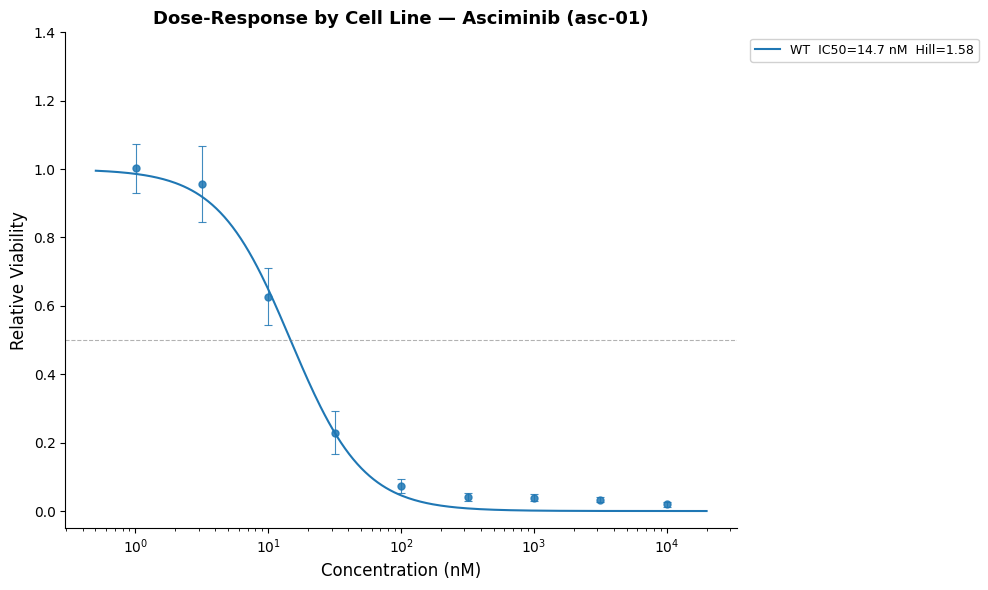

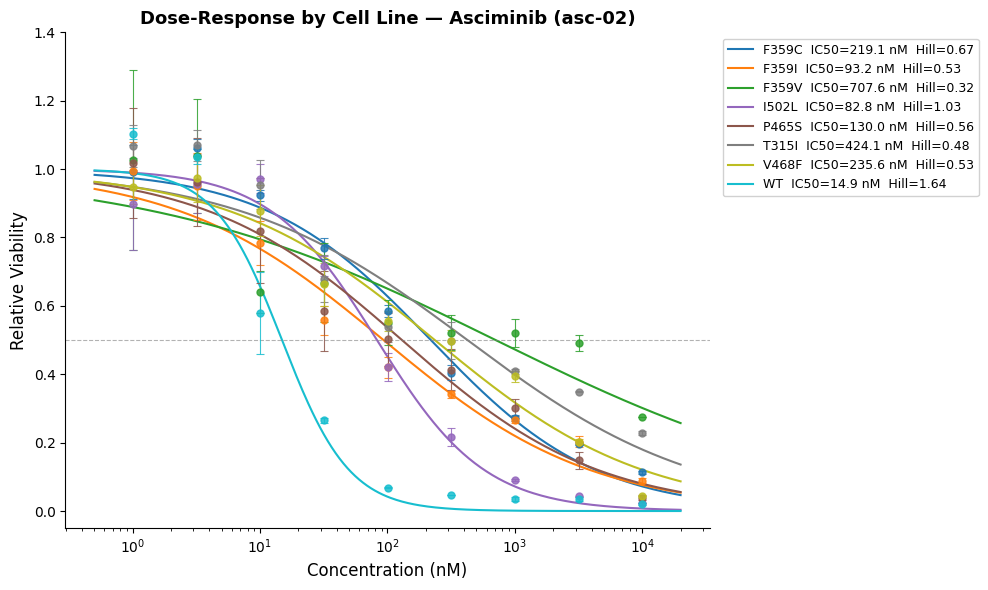

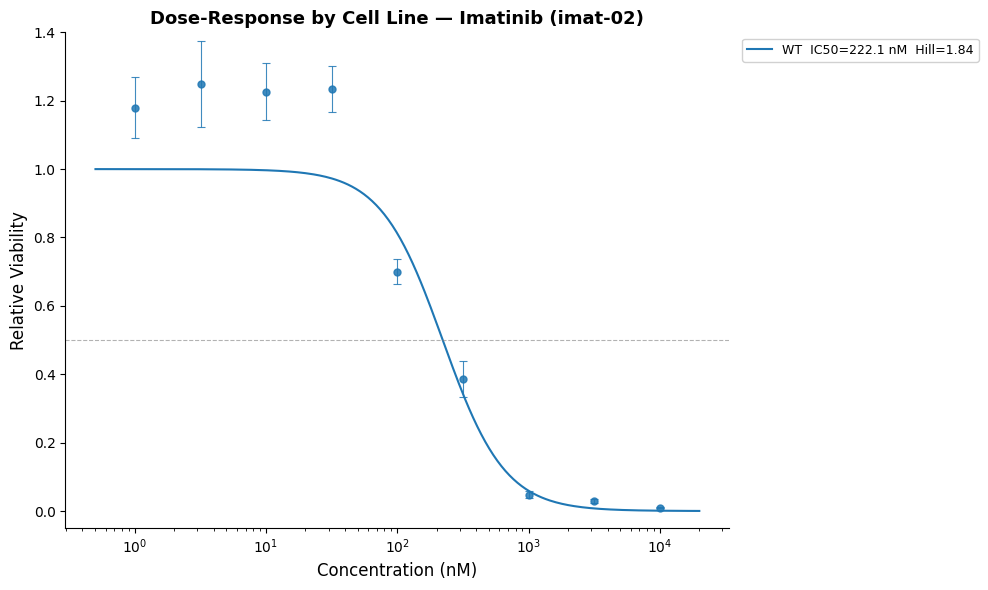

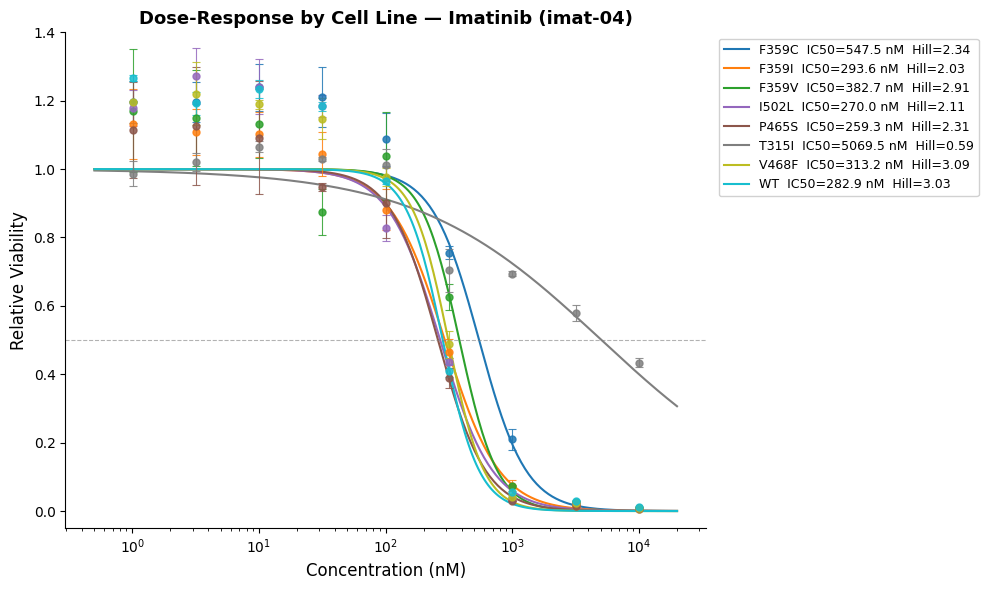

Generating per-cell-line plots...


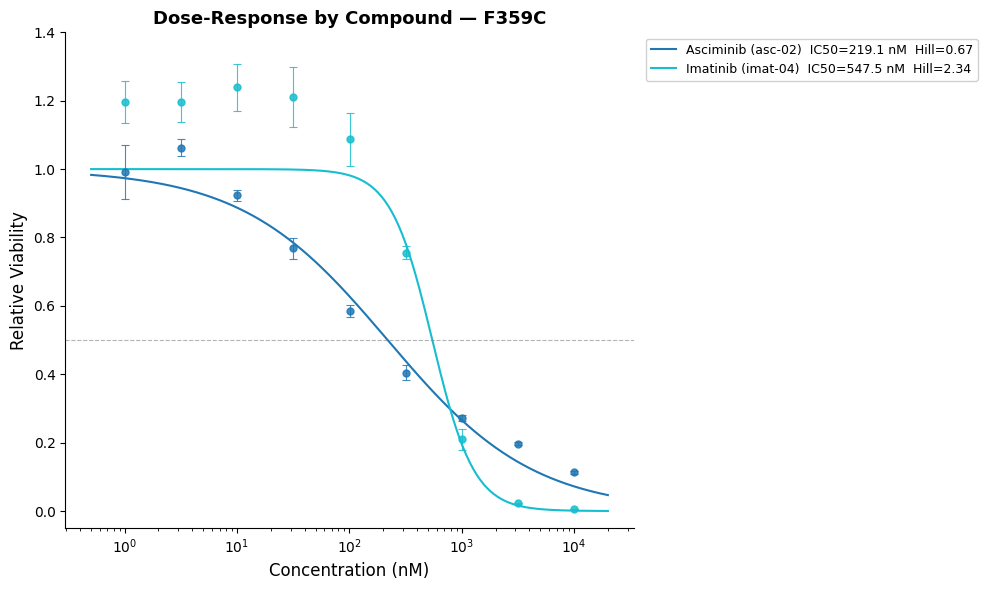

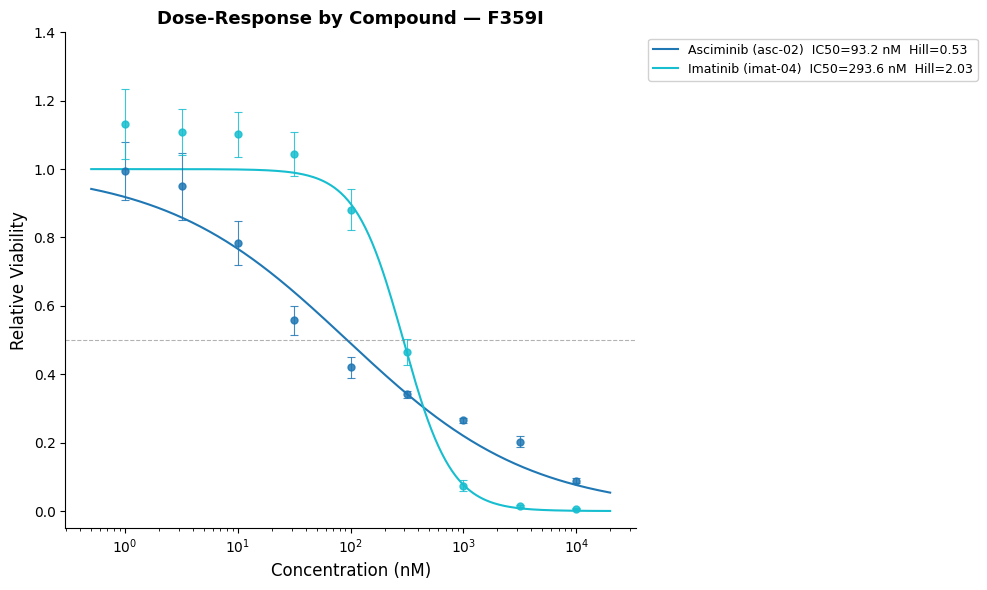

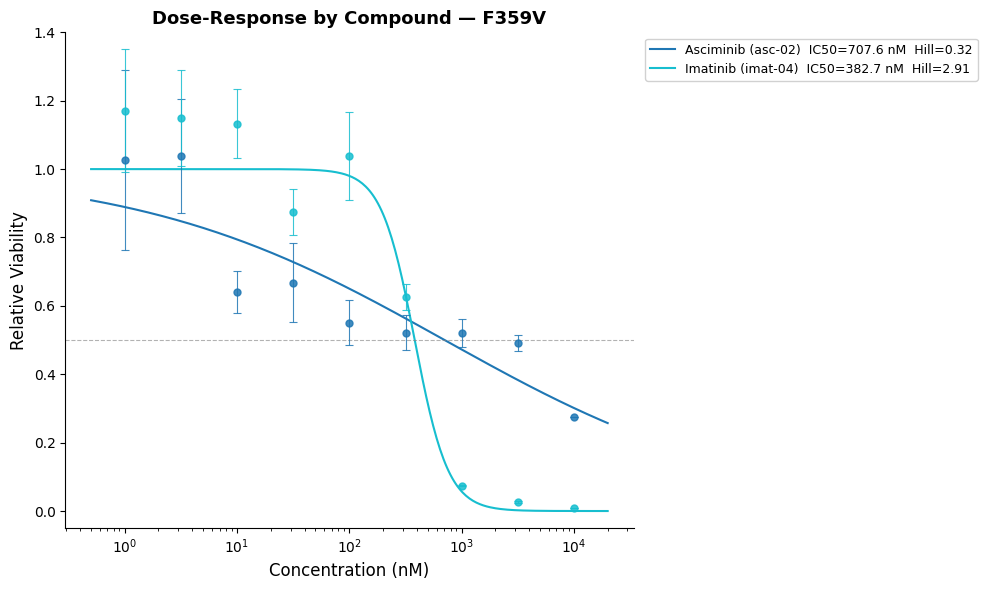

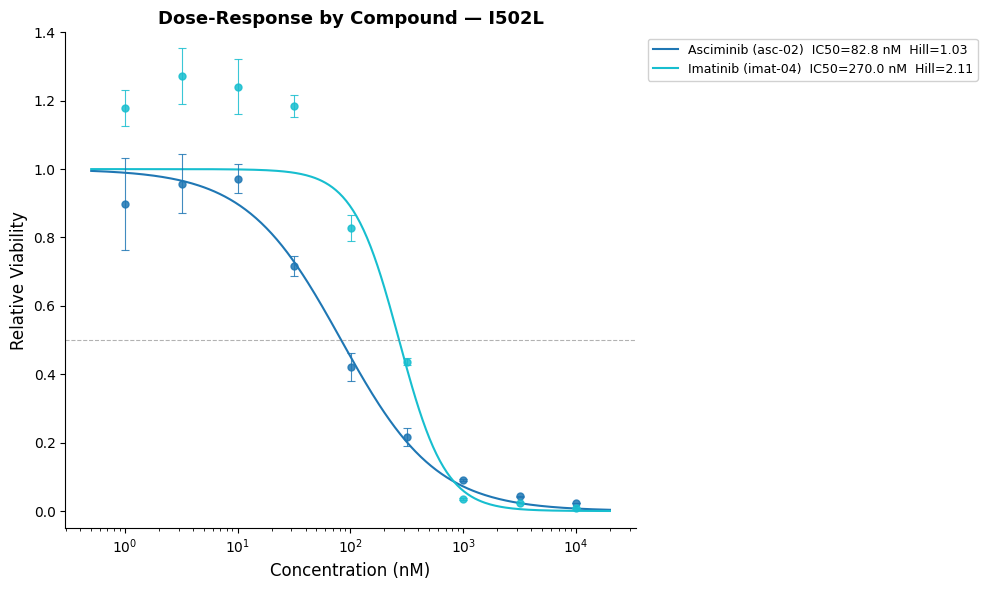

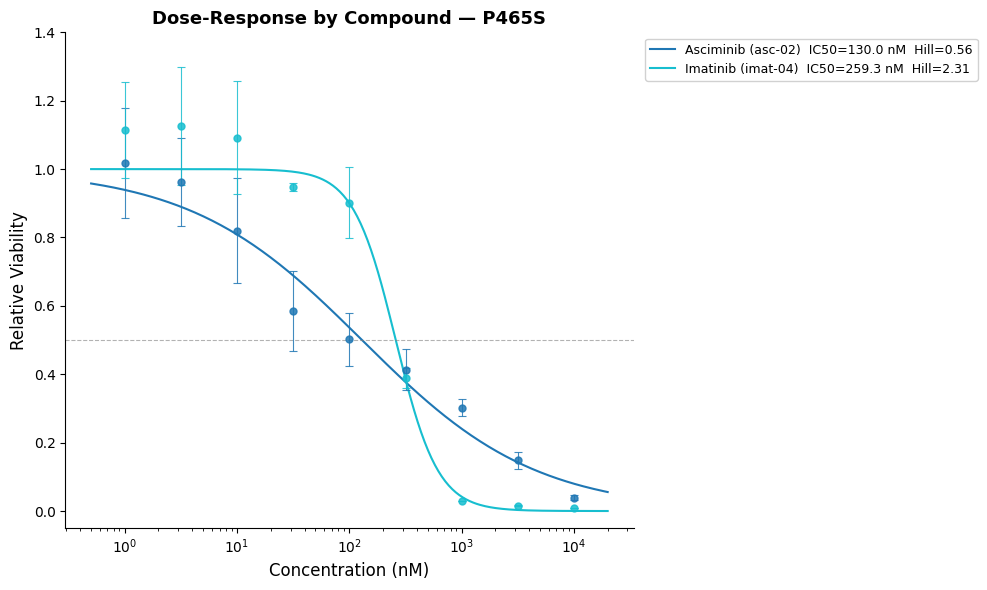

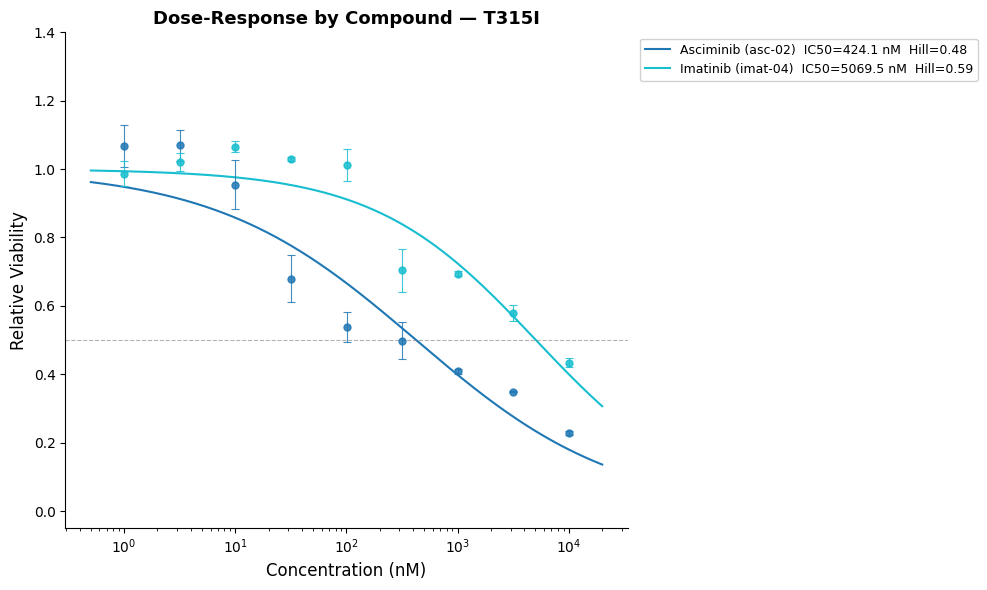

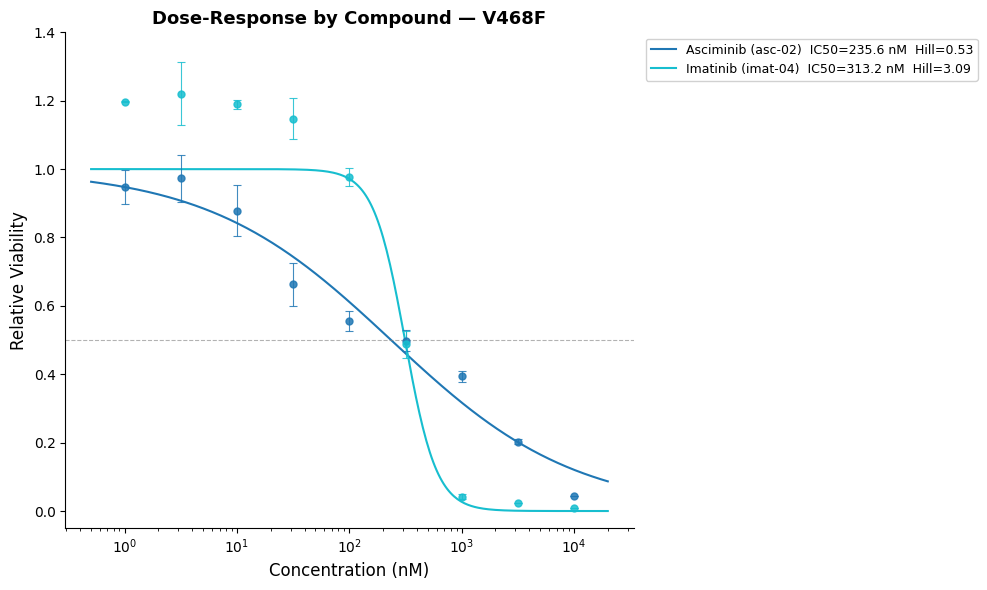

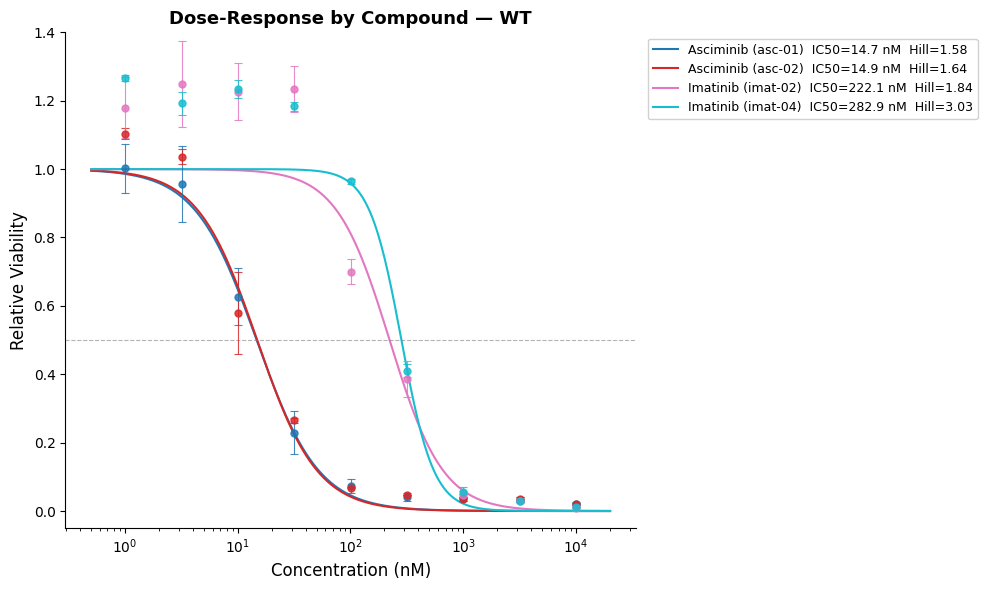


✅  12 plots saved to plots/


In [7]:
# @title Cell 7 — Dose-response plots (per drug & per cell line)
import os
os.makedirs("plots", exist_ok=True)
plot_files = []

# ── Display label logic ───────────────────────────────────────
# Rule: if a Name has more than one unique Lot in the dataset,
# display as "Name (Lot)". Applies to both cell lines and compounds.
# If Other Additives present: append " [additive]" to label.

cl_lot_counts = df.groupby("cell_line")["cell_line_lot"].nunique()
MULTI_LOT_CLS = set(cl_lot_counts[cl_lot_counts > 1].index)

cp_lot_counts = df.groupby("compound_name")["compound_lot"].nunique()
MULTI_LOT_CPS = set(cp_lot_counts[cp_lot_counts > 1].index)

def cl_label(cell_line, cell_line_lot):
    if cell_line in MULTI_LOT_CLS and cell_line_lot:
        return f"{cell_line} ({cell_line_lot})"
    return cell_line or cell_line_lot

def cp_label(compound_name, compound_lot):
    if compound_name in MULTI_LOT_CPS and compound_lot:
        return f"{compound_name} ({compound_lot})"
    return compound_name or compound_lot

def make_drc_plot(groupby_col, groupby_val, color_col, title_prefix, fname):
    subset = df[df["conc_nm"] > 0].copy()
    subset = subset[subset[groupby_col] == groupby_val]

    # Build series: unique combos of color_col (+ other_additives if present)
    series_cols = [color_col]
    if has_other:
        series_cols = list(dict.fromkeys(series_cols + ["other_additives"]))

    series_keys = (subset[series_cols]
                   .drop_duplicates()
                   .sort_values(series_cols)
                   .to_dict("records"))

    cmap   = plt.cm.get_cmap("tab10", len(series_keys))
    doses  = subset["conc_nm"]
    x_fit  = np.logspace(np.log10(doses.min()*0.5), np.log10(doses.max()*2), 300)
    fig, ax = plt.subplots(figsize=(10, 6))

    for idx, key in enumerate(series_keys):
        color = cmap(idx)
        mask  = pd.Series([True]*len(subset), index=subset.index)
        for col, val in key.items():
            mask &= (subset[col] == val)
        grp = subset[mask]

        sem = grp.groupby("conc_nm")["rel_via"].agg(
                  Mean="mean", SEM=lambda x: x.sem()).reset_index()
        ax.errorbar(sem["conc_nm"], sem["Mean"], yerr=sem["SEM"],
                    fmt="o", color=color, markersize=5,
                    capsize=3, capthick=0.8, elinewidth=0.8, zorder=3, alpha=0.85)

        # Look up fit params
        p_mask = pd.Series([True]*len(params_df), index=params_df.index)
        for col, val in key.items():
            if col in params_df.columns:
                p_mask &= (params_df[col] == val)
        if groupby_col in params_df.columns:
            p_mask &= (params_df[groupby_col] == groupby_val)
        p_row = params_df[p_mask]

        # Build legend label
        r0      = grp.iloc[0]
        add_str = f" [{r0['other_additives']}]" if r0["other_additives"] else ""
        if groupby_col == "compound_lot":
            legend_str = cl_label(r0["cell_line"], r0["cell_line_lot"]) + add_str
        else:
            legend_str = cp_label(r0["compound_name"], r0["compound_lot"]) + add_str

        if not p_row.empty:
            ic50 = p_row["IC50_nM"].values[0]
            hill = p_row["Hill"].values[0]
            if not (np.isnan(ic50) or np.isnan(hill)):
                ax.plot(x_fit, four_pl(x_fit, ic50, hill), color=color,
                        label=f"{legend_str}  IC50={ic50:.1f} nM  Hill={hill:.2f}")
            else:
                ax.plot([], [], color=color, label=f"{legend_str}  (fit failed)")

    # Title: Name (Lot) if multiple lots exist for this name
    if groupby_col == "compound_lot":
        cp_name = (df.loc[df["compound_lot"]==groupby_val,"compound_name"]
                   .dropna().iloc[0] if len(df.loc[df["compound_lot"]==groupby_val]) else "")
        title_val = cp_label(cp_name, groupby_val)
    else:
        cl_name = (df.loc[df["cell_line_lot"]==groupby_val,"cell_line"]
                   .dropna().iloc[0] if len(df.loc[df["cell_line_lot"]==groupby_val]) else "")
        title_val = cl_label(cl_name, groupby_val)

    ax.set_xscale("log")
    ax.set_xlabel("Concentration (nM)", fontsize=12)
    ax.set_ylabel("Relative Viability", fontsize=12)
    ax.set_title(f"{title_prefix} — {title_val}", fontsize=13, fontweight="bold")
    ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)
    ax.set_ylim(-0.05, 1.4)
    ax.legend(fontsize=9, framealpha=0.9, bbox_to_anchor=(1.01,1), loc="upper left")
    ax.spines[["top","right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()
    return fname

# Per-compound plots
print("Generating per-compound plots...")
for cp in sorted(df["compound_lot"].unique()):
    safe = cp.replace("/","_").replace(" ","_")
    fname = f"plots/drc_compound_{safe}.png"
    make_drc_plot("compound_lot", cp, "cell_line_lot",
                  "Dose-Response by Cell Line", fname)
    plot_files.append(fname)

# Per-cell-line plots
print("Generating per-cell-line plots...")
for cl_lot in sorted(df["cell_line_lot"].unique()):
    safe = cl_lot.replace("/","_").replace(" ","_")
    fname = f"plots/drc_cellline_{safe}.png"
    make_drc_plot("cell_line_lot", cl_lot, "compound_lot",
                  "Dose-Response by Compound", fname)
    plot_files.append(fname)

print(f"\n✅  {len(plot_files)} plots saved to plots/")


In [8]:
# @title Cell 8 — Bundle outputs and download zip
import zipfile, shutil, os
from google.colab import drive

# ── Google Drive destination ──────────────────────────────────
# Set this to the folder in your shared drive where results should be saved.
# The path must start with /content/drive/
GDRIVE_SAVE_PATH = "/content/drive/Shareddrives/99_Archived/Data/IC50s/results"
# ─────────────────────────────────────────────────────────────

# Mount Google Drive (will prompt for auth if not already mounted)
if not os.path.exists("/content/drive"):
    drive.mount("/content/drive")
else:
    print("Google Drive already mounted.")

exp_id    = layout_fname.replace("plate_layout_","").replace(".xlsx","")
datestamp = __import__('datetime').datetime.now().strftime('%y%m%d%H%M')
zip_name  = f"ic50_results_{exp_id}_{datestamp}.zip"

# Save results CSV
csv_name = f"ic50_results_{exp_id}_{datestamp}.csv"
results_df["notebook_version"] = NOTEBOOK_VERSION
results_df.to_csv(csv_name, index=False)

with zipfile.ZipFile(zip_name, "w", zipfile.ZIP_DEFLATED) as zf:

    # 1. Input files (record keeping)
    zf.write(layout_fname, f"inputs/{layout_fname}")
    zf.write(reader_fname, f"inputs/{reader_fname}")

    # 2. Results CSV
    zf.write(csv_name, f"results/{csv_name}")

    # 3. All plots
    for fpath in plot_files:
        zf.write(fpath, f"plots/{os.path.basename(fpath)}")

print(f"\nZip contents:")
with zipfile.ZipFile(zip_name, "r") as zf:
    for name in sorted(zf.namelist()):
        info = zf.getinfo(name)
        print(f"  {name:<60} {info.file_size/1024:>8.1f} KB")

# ── Save to Google Drive ──────────────────────────────────────
try:
    os.makedirs(GDRIVE_SAVE_PATH, exist_ok=True)
    gdrive_dest = os.path.join(GDRIVE_SAVE_PATH, zip_name)
    shutil.copy(zip_name, gdrive_dest)
    print(f"\n✅  Saved to Google Drive: {gdrive_dest}")
except Exception as e:
    print(f"\n⚠️  Could not save to Google Drive: {e}")
    print(    "    Check that GDRIVE_SAVE_PATH is correct and the drive is mounted.")

# ── Download to local machine ─────────────────────────────────
files.download(zip_name)
print(f"✅  Downloaded locally: {zip_name}")


Mounted at /content/drive

Zip contents:
  inputs/Imat_Asc_ResMuts_260608.xlsx                              33.1 KB
  inputs/plate_layout_test1154_2026-06-25.xlsx                     20.7 KB
  plots/drc_cellline_F359C-8.png                                   83.9 KB
  plots/drc_cellline_F359I-7.png                                   85.5 KB
  plots/drc_cellline_F359V-3.png                                   84.1 KB
  plots/drc_cellline_I502L-14.png                                  82.2 KB
  plots/drc_cellline_P465S-9.png                                   84.9 KB
  plots/drc_cellline_T315I-2.png                                   83.2 KB
  plots/drc_cellline_V468F-13.png                                  83.7 KB
  plots/drc_cellline_WT-1.png                                     108.3 KB
  plots/drc_compound_asc-01.png                                    60.4 KB
  plots/drc_compound_asc-02.png                                   192.3 KB
  plots/drc_compound_imat-02.png                           

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅  Downloaded locally: ic50_results_test1154_2026-06-25_2606251614.zip
